## Step 0 — Install Dependencies

In [1]:
!pip install -q segmentation-models-pytorch albumentations ultralytics
# fvcore for FLOPs counting (optional — skipped gracefully if unavailable)
!pip install -q fvcore 2>/dev/null || true
print("✅ Dependencies installed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
✅ Dependencies installed


## Step 1 — Imports & Configuration

In [2]:
import os, cv2, json, time, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import pandas as pd
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
from ultralytics import YOLO
from pathlib import Path
from google.colab import drive

# ── CONFIG — edit only this cell ──────────────────────────────────────────────
CONFIG = {
    # ── Dataset ───────────────────────────────────────────────────────────────
    "image_dir"        : "/content/drive/MyDrive/FYP/data/images",
    "mask_dir"         : "/content/drive/MyDrive/FYP/data/masks",
    "test_fraction"    : 0.20,          # use 20% of available test images
    "seed"             : 42,

    # ── Models ────────────────────────────────────────────────────────────────
    "yolo_weights"     : "/content/drive/MyDrive/FYP/yolo_runs/roi_detect/weights/best.pt",
    "seg_weights"      : "/content/drive/MyDrive/FYP/FineTune/finetune_unetpp_roi_best.pth",

    # ── Architecture ──────────────────────────────────────────────────────────
    "num_classes"      : 6,
    "seg_image_size"   : 256,           # used for baseline resize before seg inference

    # ── YOLO detection ────────────────────────────────────────────────────────
    "yolo_conf"        : 0.25,          # confidence threshold
    "yolo_iou"         : 0.45,          # NMS IoU threshold
    "yolo_imgsz"       : 640,

    # ── ROI crop padding (asymmetric) ─────────────────────────────────────────
    "x_pad_frac"       : 0.60,          # 30% extra padding on left/right
    "y_pad_frac"       : 0.40,          # 10% extra padding on top/bottom

    # ── Output paths (all on Drive) ───────────────────────────────────────────
    "output_dir"       : "/content/drive/MyDrive/FYP/pipeline1/pipeline_outputs",
    "pred_mask_dir"    : "/content/drive/MyDrive/FYP/pipeline1/pipeline_outputs/pred_masks",
    "viz_dir"          : "/content/drive/MyDrive/FYP/pipeline1/pipeline_outputs/visualisations",
    "metrics_csv"      : "/content/drive/MyDrive/FYP/pipeline1/pipeline_outputs/metrics.csv",
    "summary_json"     : "/content/drive/MyDrive/FYP/pipeline1/pipeline_outputs/summary.json",
}

NUM_CLASSES  = CONFIG["num_classes"]
CLASS_NAMES  = ["Background", "Retinal Layer", "PED", "SRF", "IRF", "RPE"]

torch.manual_seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])
random.seed(CONFIG["seed"])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device      : {device}")
if torch.cuda.is_available():
    print(f"GPU         : {torch.cuda.get_device_name(0)}")
print(f"NUM_CLASSES : {NUM_CLASSES}")
print(f"Test subset : {CONFIG['test_fraction']*100:.0f}%  (seed={CONFIG['seed']})")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Device      : cuda
GPU         : Tesla T4
NUM_CLASSES : 6
Test subset : 20%  (seed=42)


In [3]:
drive.mount("/content/drive")

# ── Create output directories ─────────────────────────────────────────────────
for d in [CONFIG["output_dir"], CONFIG["pred_mask_dir"], CONFIG["viz_dir"]]:
    os.makedirs(d, exist_ok=True)
    print(f"  📁 {d}")
print("✅ Drive mounted · Output directories ready")

Mounted at /content/drive
  📁 /content/drive/MyDrive/FYP/pipeline1/pipeline_outputs
  📁 /content/drive/MyDrive/FYP/pipeline1/pipeline_outputs/pred_masks
  📁 /content/drive/MyDrive/FYP/pipeline1/pipeline_outputs/visualisations
✅ Drive mounted · Output directories ready


## Step 2 — Class Mapping & Helper Functions


In [4]:
# ── Class colour map (identical to baseline) ──────────────────────────────────
CLASS_INFO = {
    0: {"name": "Background",    "rgb": (0,   0,   0)},
    1: {"name": "Retinal Layer", "rgb": (255, 0,   255)},  # Magenta
    2: {"name": "PED",           "rgb": (255, 255, 0)},    # Yellow
    3: {"name": "SRF",           "rgb": (255, 0,   0)},    # Red
    4: {"name": "IRF",           "rgb": (0,   0,   255)},  # Blue
    5: {"name": "RPE",           "rgb": (0,   255, 0)},    # Green
}

CLASS_COLORS_VIZ = [
    [0,   0,   0  ],   # 0 Background  — black
    [255, 0,   255],   # 1 Retinal     — magenta
    [255, 255, 0  ],   # 2 PED         — yellow
    [255, 0,   0  ],   # 3 SRF         — red
    [0,   0,   255],   # 4 IRF         — blue
    [0,   255, 0  ],   # 5 RPE         — green
]

print("── Class Mapping ──────────────────────────────────────")
for cls_id, info in CLASS_INFO.items():
    r, g, b = info["rgb"]
    print(f"  Class {cls_id}: {info['name']:<18} RGB({r:3d},{g:3d},{b:3d})")


def rgb_mask_to_class(mask_bgr, class_info=CLASS_INFO, tolerance=40):
    """Convert a BGR colour mask → integer class label map (H, W).
    Identical to baseline implementation.
    """
    mask_rgb  = cv2.cvtColor(mask_bgr, cv2.COLOR_BGR2RGB)
    h, w, _   = mask_rgb.shape
    pixels    = mask_rgb.reshape(-1, 3).astype(np.float32)
    best_dist = np.full(len(pixels), np.inf)
    best_cls  = np.zeros(len(pixels), dtype=np.uint8)
    for cls_id, info in class_info.items():
        ref  = np.array(info["rgb"], dtype=np.float32)
        dist = np.linalg.norm(pixels - ref, axis=1)
        better = dist < best_dist
        best_dist[better] = dist[better]
        best_cls[better]  = cls_id
    return best_cls.reshape(h, w)


def mask_to_rgb(mask_np):
    """Integer class map → RGB visualisation array (H, W, 3).
    Identical to baseline implementation.
    """
    h, w = mask_np.shape
    rgb  = np.zeros((h, w, 3), dtype=np.uint8)
    for c in range(NUM_CLASSES):
        rgb[mask_np == c] = CLASS_COLORS_VIZ[c]
    return rgb


# ── Metric helpers (identical metric style to baseline) ───────────────────────
def dice_score_np(pred_cls, gt_cls, smooth=1e-6):
    """Mean Dice over all classes (numpy arrays)."""
    scores = []
    for c in range(NUM_CLASSES):
        p     = (pred_cls == c).astype(np.float32)
        t     = (gt_cls   == c).astype(np.float32)
        inter = (p * t).sum()
        scores.append((2 * inter + smooth) / (p.sum() + t.sum() + smooth))
    return float(np.mean(scores))

def iou_score_np(pred_cls, gt_cls, smooth=1e-6):
    """Mean IoU over all classes (numpy arrays)."""
    scores = []
    for c in range(NUM_CLASSES):
        p     = (pred_cls == c).astype(np.float32)
        t     = (gt_cls   == c).astype(np.float32)
        inter = (p * t).sum()
        union = p.sum() + t.sum() - inter
        scores.append((inter + smooth) / (union + smooth))
    return float(np.mean(scores))

def pixel_accuracy_np(pred_cls, gt_cls):
    """Fraction of correctly classified pixels."""
    return float((pred_cls == gt_cls).mean())

def sensitivity_specificity_np(pred_cls, gt_cls, smooth=1e-6):
    """Mean sensitivity and specificity across all classes."""
    sens_list, spec_list = [], []
    for c in range(NUM_CLASSES):
        tp = float(((pred_cls == c) & (gt_cls == c)).sum())
        fn = float(((pred_cls != c) & (gt_cls == c)).sum())
        tn = float(((pred_cls != c) & (gt_cls != c)).sum())
        fp = float(((pred_cls == c) & (gt_cls != c)).sum())
        sens_list.append((tp + smooth) / (tp + fn + smooth))
        spec_list.append((tn + smooth) / (tn + fp + smooth))
    return float(np.mean(sens_list)), float(np.mean(spec_list))

def per_class_dice_np(pred_cls, gt_cls, smooth=1e-6):
    """Per-class Dice scores (numpy arrays)."""
    scores = []
    for c in range(NUM_CLASSES):
        p     = (pred_cls == c).astype(np.float32)
        t     = (gt_cls   == c).astype(np.float32)
        inter = (p * t).sum()
        scores.append(float((2 * inter + smooth) / (p.sum() + t.sum() + smooth)))
    return scores

def per_class_iou_np(pred_cls, gt_cls, smooth=1e-6):
    """Per-class IoU scores (numpy arrays)."""
    scores = []
    for c in range(NUM_CLASSES):
        p     = (pred_cls == c).astype(np.float32)
        t     = (gt_cls   == c).astype(np.float32)
        inter = (p * t).sum()
        union = p.sum() + t.sum() - inter
        scores.append(float((inter + smooth) / (union + smooth)))
    return scores

print("\n✅ Helper functions defined")

── Class Mapping ──────────────────────────────────────
  Class 0: Background         RGB(  0,  0,  0)
  Class 1: Retinal Layer      RGB(255,  0,255)
  Class 2: PED                RGB(255,255,  0)
  Class 3: SRF                RGB(255,  0,  0)
  Class 4: IRF                RGB(  0,  0,255)
  Class 5: RPE                RGB(  0,255,  0)

✅ Helper functions defined


## Step 3 — Load 20% Test Subset



In [5]:
# ── Collect all paired image/mask files ───────────────────────────────────────
IMG_EXTS = ('.png', '.jpg', '.jpeg', '.tif', '.bmp')

all_images = sorted([
    f for f in os.listdir(CONFIG["image_dir"])
    if f.lower().endswith(IMG_EXTS)
])

# Keep only images that have a matching mask
paired = []
for fname in all_images:
    mask_path = os.path.join(CONFIG["mask_dir"], fname)
    if os.path.exists(mask_path):
        paired.append(fname)
    else:
        # Try common alternative extensions
        stem = os.path.splitext(fname)[0]
        for ext in IMG_EXTS:
            alt = stem + ext
            if os.path.exists(os.path.join(CONFIG["mask_dir"], alt)):
                paired.append(fname)
                break

print(f"Total paired image-mask files : {len(paired)}")

# ── Randomly sample 20% ───────────────────────────────────────────────────────
rng = random.Random(CONFIG["seed"])
rng.shuffle(paired)

n_subset = max(1, int(len(paired) * CONFIG["test_fraction"]))
test_files = paired[:n_subset]

print(f"20% subset size               : {n_subset} images")
print(f"Seed used                     : {CONFIG['seed']}")
print(f"\nFirst 5 selected files:")
for f in test_files[:5]:
    print(f"  {f}")

Total paired image-mask files : 3049
20% subset size               : 609 images
Seed used                     : 42

First 5 selected files:
  2506.png
  1531.png
  103.png
  1594.png
  2881.png


## Step 4 — Load YOLOv8n ROI Detector



In [6]:
yolo_path = CONFIG["yolo_weights"]
assert os.path.exists(yolo_path), (
    f"YOLO weights not found:\n  {yolo_path}\n"
    "Check CONFIG['yolo_weights'] and re-run."
)

yolo_model = YOLO(yolo_path)
yolo_model.to(device)

# ── Model info ────────────────────────────────────────────────────────────────
n_yolo_params = sum(p.numel() for p in yolo_model.model.parameters())
print(f"── YOLOv8n ROI Detector ──────────────────────────────────")
print(f"  Weights   : {yolo_path}")
print(f"  Params    : {n_yolo_params:,} ({n_yolo_params/1e6:.2f}M)")
print(f"  Conf thr  : {CONFIG['yolo_conf']}")
print(f"  IoU  thr  : {CONFIG['yolo_iou']}")
print(f"  Input sz  : {CONFIG['yolo_imgsz']}")
print(f"  Device    : {device}")
print("✅ YOLOv8n loaded")

── YOLOv8n ROI Detector ──────────────────────────────────
  Weights   : /content/drive/MyDrive/FYP/yolo_runs/roi_detect/weights/best.pt
  Params    : 3,011,043 (3.01M)
  Conf thr  : 0.25
  IoU  thr  : 0.45
  Input sz  : 640
  Device    : cuda
✅ YOLOv8n loaded


## Step 5 — Load UNet++ Segmentation Model


In [7]:
# ── Build architecture (identical to baseline) ────────────────────────────────
seg_model = smp.UnetPlusPlus(
    encoder_name          = "efficientnet-b4",
    encoder_weights       = None,          # weights loaded from checkpoint
    in_channels           = 1,
    classes               = NUM_CLASSES,
    activation            = None,
    decoder_channels      = (256, 128, 64, 32, 16),
    decoder_use_batchnorm = True,
)
seg_model = seg_model.to(device)

# ── Load checkpoint ───────────────────────────────────────────────────────────
seg_path = CONFIG["seg_weights"]
assert os.path.exists(seg_path), (
    f"Segmentation checkpoint not found:\n  {seg_path}\n"
    "Check CONFIG['seg_weights'] and re-run."
)

ckpt = torch.load(seg_path, map_location=device)
seg_model.load_state_dict(ckpt["model_state"])
seg_model.eval()

n_seg_params = sum(p.numel() for p in seg_model.parameters())
print(f"── UNet++ EfficientNet-B4 ────────────────────────────────")
print(f"  Checkpoint : {seg_path}")
print(f"  Epoch      : {ckpt.get('epoch', '?')}")
print(f"  Val Dice   : {ckpt.get('dice',  '?')}")
print(f"  Params     : {n_seg_params:,} ({n_seg_params/1e6:.2f}M)")
print(f"  Classes    : {NUM_CLASSES}")
print(f"  Device     : {device}")
print("✅ Segmentation model loaded")


# ── Stride-32 padding utility (needed by EfficientNet-B4 encoder) ────────────
def pad_to_stride32(img_np_gray):
    """Pad a grayscale numpy image (H, W) so both dims are divisible by 32.
    Returns (padded_tensor, (orig_h, orig_w)) for later unpadding.
    """
    h, w   = img_np_gray.shape
    ph     = int(np.ceil(h / 32) * 32)
    pw     = int(np.ceil(w / 32) * 32)
    padded = np.zeros((ph, pw), dtype=img_np_gray.dtype)
    padded[:h, :w] = img_np_gray
    return padded, (h, w)

── UNet++ EfficientNet-B4 ────────────────────────────────
  Checkpoint : /content/drive/MyDrive/FYP/FineTune/finetune_unetpp_roi_best.pth
  Epoch      : 55
  Val Dice   : 0.7772065323705857
  Params     : 20,812,974 (20.81M)
  Classes    : 6
  Device     : cuda
✅ Segmentation model loaded


## Step 6 — ROI Detection Function



In [8]:
def detect_roi(img_bgr, yolo_model, conf=0.25, iou=0.45, imgsz=640):

    H, W = img_bgr.shape[:2]

    results = yolo_model.predict(
        img_bgr,
        conf    = conf,
        iou     = iou,
        imgsz   = imgsz,
        verbose = False,
    )[0]

    if results.boxes is None or len(results.boxes) == 0:
        # ── Fallback: no detection → use full image as ROI ────────────────────
        return (0, 0, W, H), 0.0, False

    # ── Pick highest-confidence box ───────────────────────────────────────────
    boxes      = results.boxes
    conf_vals  = boxes.conf.cpu().numpy()
    best_idx   = int(np.argmax(conf_vals))
    x1, y1, x2, y2 = map(int, boxes.xyxy[best_idx].cpu().numpy())

    # Clamp to image boundaries (safety)
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(W, x2), min(H, y2)

    return (x1, y1, x2, y2), float(conf_vals[best_idx]), True


# ── Quick smoke-test on first image ──────────────────────────────────────────
_fname    = test_files[0]
_img_bgr  = cv2.imread(os.path.join(CONFIG["image_dir"], _fname))
_box, _c, _det = detect_roi(_img_bgr, yolo_model,
                             conf=CONFIG["yolo_conf"],
                             iou=CONFIG["yolo_iou"],
                             imgsz=CONFIG["yolo_imgsz"])
print(f"Smoke-test on: {_fname}")
print(f"  Detected : {_det}  |  Confidence : {_c:.3f}")
print(f"  Box (x1,y1,x2,y2) : {_box}")
print(f"  Box size : {_box[2]-_box[0]} × {_box[3]-_box[1]}  (W × H)")

Smoke-test on: 2506.png
  Detected : True  |  Confidence : 0.334
  Box (x1,y1,x2,y2) : (4, 182, 569, 226)
  Box size : 565 × 44  (W × H)


## Step 7 — Asymmetric ROI Crop & Reconstruction




In [9]:
def crop_roi(img_gray, box, x_pad_frac=0.60, y_pad_frac=0.40):

    H, W = img_gray.shape
    x1, y1, x2, y2 = box

    box_w = x2 - x1
    box_h = y2 - y1

    # ── Asymmetric padding (30% horizontal, 10% vertical) ─────────────────────
    pad_x = int(round(box_w * x_pad_frac))   # pixels to add on each side (L & R)
    pad_y = int(round(box_h * y_pad_frac))   # pixels to add on top & bottom

    # ── Expand and clamp to image boundaries ──────────────────────────────────
    cx1 = max(0,   x1 - pad_x)
    cy1 = max(0,   y1 - pad_y)
    cx2 = min(W,   x2 + pad_x)
    cy2 = min(H,   y2 + pad_y)

    crop        = img_gray[cy1:cy2, cx1:cx2]
    crop_coords = (cx1, cy1, cx2, cy2)

    return crop, crop_coords


def reconstruct_full_mask(roi_pred_cls, crop_coords, full_shape):

    H, W = full_shape
    cx1, cy1, cx2, cy2 = crop_coords

    full_mask = np.zeros((H, W), dtype=np.uint8)   # background outside ROI
    full_mask[cy1:cy2, cx1:cx2] = roi_pred_cls.astype(np.uint8)

    return full_mask


# ── Verify crop & reconstruct on smoke-test image ─────────────────────────────
_img_gray = cv2.imread(os.path.join(CONFIG["image_dir"], _fname), cv2.IMREAD_GRAYSCALE)
_crop, _coords = crop_roi(_img_gray, _box,
                           x_pad_frac=CONFIG["x_pad_frac"],
                           y_pad_frac=CONFIG["y_pad_frac"])

print(f"Full image size : {_img_gray.shape}  (H × W)")
print(f"YOLO box        : {_box}")
print(f"Crop coords     : {_coords}")
print(f"Crop size       : {_crop.shape}  (H × W)  — native, no resize")
print(f"x_pad={CONFIG['x_pad_frac']*100:.0f}%  y_pad={CONFIG['y_pad_frac']*100:.0f}%")

# Check reconstruction round-trip
_dummy_roi_mask = np.ones(_crop.shape, dtype=np.uint8)
_recon = reconstruct_full_mask(_dummy_roi_mask, _coords, _img_gray.shape)
print(f"Reconstruction  : {_recon.shape}  — matches full image ✅")

Full image size : (380, 570)  (H × W)
YOLO box        : (4, 182, 569, 226)
Crop coords     : (0, 164, 570, 244)
Crop size       : (80, 570)  (H × W)  — native, no resize
x_pad=60%  y_pad=40%
Reconstruction  : (380, 570)  — matches full image ✅


## Step 8 — Segmentation Inference on ROI Crop



In [10]:
def segment_roi(crop_gray, seg_model, device):

    h_orig, w_orig = crop_gray.shape

    # ── Normalise (identical to baseline get_transforms norm) ─────────────────
    img_f = crop_gray.astype(np.float32)
    img_f = (img_f / 255.0 - 0.5) / 0.5    # → [-1, 1]

    # ── Pad to multiple of 32 (EfficientNet-B4 stride requirement) ────────────
    img_padded, (h_orig2, w_orig2) = pad_to_stride32(img_f)

    # ── Build tensor (1, 1, H_pad, W_pad) ────────────────────────────────────
    tensor = torch.tensor(img_padded, dtype=torch.float32)                   .unsqueeze(0).unsqueeze(0).to(device)

    # ── Forward pass ──────────────────────────────────────────────────────────
    with torch.no_grad():
        logits = seg_model(tensor)                        # (1, C, H_pad, W_pad)

    # ── Argmax → class map, crop back to original crop size ───────────────────
    pred_full = logits.argmax(dim=1).squeeze(0).cpu().numpy()   # (H_pad, W_pad)
    pred_cls  = pred_full[:h_orig, :w_orig].astype(np.uint8)    # (H_c, W_c)

    return pred_cls


# ── Smoke-test segmentation ───────────────────────────────────────────────────
_seg_start = time.time()
_roi_pred  = segment_roi(_crop, seg_model, device)
_seg_time  = time.time() - _seg_start

print(f"ROI crop input   : {_crop.shape}  (H × W)")
print(f"ROI pred output  : {_roi_pred.shape}  (H × W)")
print(f"Unique classes   : {np.unique(_roi_pred).tolist()}")
print(f"Seg inference    : {_seg_time*1000:.1f} ms")

ROI crop input   : (80, 570)  (H × W)
ROI pred output  : (80, 570)  (H × W)
Unique classes   : [0, 1, 2, 3, 4]
Seg inference    : 183.8 ms


## Step 9 — Full Single-Image Pipeline

`run_pipeline` orchestrates all steps for one image:

1. **YOLO detect** → bounding box  
2. **Asymmetric crop** → ROI at native resolution  
3. **UNet++ segment** → ROI class map  
4. **Reconstruct** → full-size prediction  
5. **Metrics** (vs. ground-truth full mask)

Returns a result dict with timings, predictions, and all metric values.


In [11]:
def run_pipeline(fname, image_dir, mask_dir,
                 yolo_model, seg_model, device, config):
    """End-to-end ROI-guided segmentation for one OCT image.

    Evaluation strategy (Fix 1)
    ---------------------------
    PRIMARY   → metrics computed on the ROI crop region only.
                pred_roi (H_crop, W_crop)  vs  gt_roi (H_crop, W_crop)
                This is the correct comparison: the model only sees the crop,
                so we should only judge it on what it was given.

    SECONDARY → metrics on the full reconstructed mask vs full GT mask.
                Stored with the suffix _full for reference / ablation.

    Returns
    -------
    result : dict  (see keys below)
    """
    t0 = time.time()

    # ── 1. Load full OCT image ────────────────────────────────────────────────
    img_path  = os.path.join(image_dir, fname)
    mask_path = os.path.join(mask_dir,  fname)

    img_bgr   = cv2.imread(img_path,  cv2.IMREAD_COLOR)
    img_gray  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    mask_bgr  = cv2.imread(mask_path, cv2.IMREAD_COLOR)

    H, W = img_gray.shape
    mask_gt_cls = rgb_mask_to_class(mask_bgr)       # (H, W) full GT

    # ── 2. YOLO: detect ROI ───────────────────────────────────────────────────
    t_det_start = time.time()
    box, confidence, detected = detect_roi(
        img_bgr, yolo_model,
        conf  = config["yolo_conf"],
        iou   = config["yolo_iou"],
        imgsz = config["yolo_imgsz"],
    )
    t_detect = time.time() - t_det_start

    # ── 3. Asymmetric crop ────────────────────────────────────────────────────
    t_crop_start = time.time()
    crop, crop_coords = crop_roi(
        img_gray, box,
        x_pad_frac = config["x_pad_frac"],
        y_pad_frac = config["y_pad_frac"],
    )
    t_crop = time.time() - t_crop_start

    cx1, cy1, cx2, cy2 = crop_coords   # pixel coords used for crop

    # ── 4. Segmentation on ROI ────────────────────────────────────────────────
    t_seg_start = time.time()
    roi_pred_cls = segment_roi(crop, seg_model, device)   # (H_crop, W_crop)
    t_seg = time.time() - t_seg_start

    # ── 5. Reconstruct full-size mask ─────────────────────────────────────────
    t_recon_start = time.time()
    full_pred_cls = reconstruct_full_mask(roi_pred_cls, crop_coords, (H, W))
    t_recon = time.time() - t_recon_start

    t_total = time.time() - t0

    # ═════════════════════════════════════════════════════════════════════════
    # ── 6a.  PRIMARY METRICS — ROI region only  (Fix 1) ─────────────────────
    #
    #   Crop the GT mask to exactly the same region that was fed to the model.
    #   Both arrays are now (H_crop, W_crop) → a fair apples-to-apples compare.
    # ═════════════════════════════════════════════════════════════════════════
    gt_roi = mask_gt_cls[cy1:cy2, cx1:cx2]     # GT cropped to ROI region

    # Ensure shapes match (guard against 1-pixel rounding at image edge)
    h_p, w_p = roi_pred_cls.shape
    gt_roi   = gt_roi[:h_p, :w_p]

    dice    = dice_score_np(roi_pred_cls,  gt_roi)
    iou     = iou_score_np(roi_pred_cls,   gt_roi)
    pix_acc = pixel_accuracy_np(roi_pred_cls, gt_roi)
    sens, spec = sensitivity_specificity_np(roi_pred_cls, gt_roi)
    pc_dice = per_class_dice_np(roi_pred_cls, gt_roi)
    pc_iou  = per_class_iou_np(roi_pred_cls,  gt_roi)

    # ═════════════════════════════════════════════════════════════════════════
    # ── 6b.  SECONDARY METRICS — full image  (kept for ablation) ────────────
    #
    #   These reproduce the OLD behaviour (full_pred vs full_gt).
    #   They will be lower because outside-ROI pixels are all predicted as 0.
    #   Stored with _full suffix so you can compare old vs new in the CSV.
    # ═════════════════════════════════════════════════════════════════════════
    dice_full    = dice_score_np(full_pred_cls,    mask_gt_cls)
    iou_full     = iou_score_np(full_pred_cls,     mask_gt_cls)
    pix_acc_full = pixel_accuracy_np(full_pred_cls, mask_gt_cls)
    sens_full, spec_full = sensitivity_specificity_np(full_pred_cls, mask_gt_cls)
    pc_dice_full = per_class_dice_np(full_pred_cls, mask_gt_cls)
    pc_iou_full  = per_class_iou_np(full_pred_cls,  mask_gt_cls)

    return {
        # ── identifiers ───────────────────────────────────────────────────────
        "fname"          : fname,

        # ── images ────────────────────────────────────────────────────────────
        "img_gray"       : img_gray,
        "img_bgr"        : img_bgr,
        "mask_gt_cls"    : mask_gt_cls,

        # ── detection ─────────────────────────────────────────────────────────
        "box"            : box,
        "confidence"     : confidence,
        "detected"       : detected,

        # ── crop ──────────────────────────────────────────────────────────────
        "crop"           : crop,
        "crop_coords"    : crop_coords,       # (cx1, cy1, cx2, cy2)
        "gt_roi"         : gt_roi,            # GT sliced to crop region

        # ── predictions ───────────────────────────────────────────────────────
        "roi_pred_cls"   : roi_pred_cls,      # (H_crop, W_crop)
        "full_pred_cls"  : full_pred_cls,     # (H, W)

        # ── PRIMARY metrics  (ROI region only — Fix 1) ────────────────────────
        "dice"           : dice,
        "iou"            : iou,
        "pixel_acc"      : pix_acc,
        "sensitivity"    : sens,
        "specificity"    : spec,
        "per_class_dice" : pc_dice,
        "per_class_iou"  : pc_iou,

        # ── SECONDARY metrics (full image — old behaviour, for ablation) ───────
        "dice_full"           : dice_full,
        "iou_full"            : iou_full,
        "pixel_acc_full"      : pix_acc_full,
        "sensitivity_full"    : sens_full,
        "specificity_full"    : spec_full,
        "per_class_dice_full" : pc_dice_full,
        "per_class_iou_full"  : pc_iou_full,

        # ── timings ───────────────────────────────────────────────────────────
        "t_detect"       : t_detect,
        "t_crop"         : t_crop,
        "t_seg"          : t_seg,
        "t_recon"        : t_recon,
        "t_total"        : t_total,
    }


# ── Smoke-test on first image — shows ROI vs Full-image metric difference ─────
_r = run_pipeline(test_files[0], CONFIG["image_dir"], CONFIG["mask_dir"],
                  yolo_model, seg_model, device, CONFIG)

cx1, cy1, cx2, cy2 = _r["crop_coords"]

print(f"Pipeline smoke-test  : {_r['fname']}")
print(f"  Detected ROI       : {_r['detected']}  conf={_r['confidence']:.3f}")
print(f"  Box (YOLO)         : {_r['box']}")
print(f"  Crop coords used   : ({cx1},{cy1}) → ({cx2},{cy2})")
print(f"  Crop size          : {_r['crop'].shape}  (H × W)")
print(f"  GT-ROI size        : {_r['gt_roi'].shape}  (H × W)  ← same as crop")
print()
print(f"  ── PRIMARY metrics (ROI only — Fix 1) ─────────────────────")
print(f"  Dice               : {_r['dice']:.4f}  ")
print(f"  IoU                : {_r['iou']:.4f}")
print(f"  Pixel Accuracy     : {_r['pixel_acc']:.4f}")
print(f"  Sensitivity        : {_r['sensitivity']:.4f}")
print(f"  Specificity        : {_r['specificity']:.4f}")
print()
print(f"  ── SECONDARY metrics (full image — old behaviour) ──────────")
print(f"  Dice_full          : {_r['dice_full']:.4f}  ")
print(f"  IoU_full           : {_r['iou_full']:.4f}   ")
print()
print(f"  ── Improvement ─────────────────────────────────────────────")
print(f"  Δ Dice             : {_r['dice'] - _r['dice_full']:+.4f}")
print(f"  Δ IoU              : {_r['iou']  - _r['iou_full']:+.4f}")
print()
print(f"  ── Timings ─────────────────────────────────────────────────")
print(f"  detect: {_r['t_detect']*1000:.1f}ms  "
      f"seg: {_r['t_seg']*1000:.1f}ms  "
      f"total: {_r['t_total']*1000:.1f}ms")

Pipeline smoke-test  : 2506.png
  Detected ROI       : True  conf=0.334
  Box (YOLO)         : (4, 182, 569, 226)
  Crop coords used   : (0,164) → (570,244)
  Crop size          : (80, 570)  (H × W)
  GT-ROI size        : (80, 570)  (H × W)  ← same as crop

  ── PRIMARY metrics (ROI only — Fix 1) ─────────────────────
  Dice               : 0.8027  
  IoU                : 0.7000
  Pixel Accuracy     : 0.9662
  Sensitivity        : 0.8880
  Specificity        : 0.9857

  ── SECONDARY metrics (full image — old behaviour) ──────────
  Dice_full          : 0.8049  
  IoU_full           : 0.7043   

  ── Improvement ─────────────────────────────────────────────
  Δ Dice             : -0.0022
  Δ IoU              : -0.0043

  ── Timings ─────────────────────────────────────────────────
  detect: 14.0ms  seg: 36.6ms  total: 754.4ms


## Step 10 — Batch Evaluation Loop


In [12]:
all_results = []
n_total     = len(test_files)
n_detected  = 0

print(f"Running pipeline on {n_total} images  ({CONFIG['test_fraction']*100:.0f}% subset)")
print(f"{'#':>5} {'File':<35} {'Det':>4} {'Dice':>7} {'IoU':>7} {'PA':>7} {'ms':>7}")
print("-" * 72)

for i, fname in enumerate(test_files):
    res = run_pipeline(
        fname,
        CONFIG["image_dir"], CONFIG["mask_dir"],
        yolo_model, seg_model, device, CONFIG,
    )
    all_results.append(res)
    if res["detected"]:
        n_detected += 1

    if (i + 1) % 10 == 0 or i == 0 or i == n_total - 1:
        print(f"{i+1:>5} {fname:<35} "
              f"{'✓' if res['detected'] else '✗':>4} "
              f"{res['dice']:>7.4f} "
              f"{res['iou']:>7.4f} "
              f"{res['pixel_acc']:>7.4f} "
              f"{res['t_total']*1000:>7.1f}")

print(f"\nDone. Detected ROI in {n_detected}/{n_total} images "
      f"({100*n_detected/n_total:.1f}%)")

Running pipeline on 609 images  (20% subset)
    # File                                 Det    Dice     IoU      PA      ms
------------------------------------------------------------------------
    1 2506.png                               ✓  0.8027  0.7000  0.9662    97.9
   10 2267.png                               ✓  0.8715  0.8016  0.9884  2374.1
   20 1086.png                               ✓  0.8763  0.8072  0.9876  1831.4
   30 2913.png                               ✓  0.7122  0.6390  0.9525  2644.3
   40 2087.png                               ✓  0.7261  0.6584  0.9405  2736.7
   50 2841.png                               ✓  0.7162  0.6701  0.9139  1526.2
   60 344.png                                ✓  0.6688  0.6427  0.9587  2223.3
   70 1013.png                               ✗  0.7757  0.7352  0.9946  2428.3
   80 1223.png                               ✓  0.7492  0.7200  0.9843  1375.7
   90 2264.png                               ✓  0.7397  0.6868  0.9843  2484.4
  100 1325.pn

## Step 11 — Metrics Summary

Aggregate metrics over all evaluated images (mean ± std).  
Per-class breakdown uses the `█` bar style from the baseline evaluation cell.


In [13]:
# ── Aggregate global metrics ──────────────────────────────────────────────────
dice_vals   = [r["dice"]        for r in all_results]
iou_vals    = [r["iou"]         for r in all_results]
pa_vals     = [r["pixel_acc"]   for r in all_results]
sens_vals   = [r["sensitivity"] for r in all_results]
spec_vals   = [r["specificity"] for r in all_results]
total_ms    = [r["t_total"]*1000 for r in all_results]
det_ms      = [r["t_detect"]*1000 for r in all_results]
seg_ms      = [r["t_seg"]*1000    for r in all_results]

def stat(lst):
    return np.mean(lst), np.std(lst)

dice_m,  dice_s  = stat(dice_vals)
iou_m,   iou_s   = stat(iou_vals)
pa_m,    pa_s    = stat(pa_vals)
sens_m,  sens_s  = stat(sens_vals)
spec_m,  spec_s  = stat(spec_vals)
fps_m            = 1000 / np.mean(total_ms)

print("═" * 60)
print("          PIPELINE EVALUATION RESULTS")
print(f"          {n_total} images  ({CONFIG['test_fraction']*100:.0f}% subset, seed={CONFIG['seed']})")
print("═" * 60)
print(f"  Dice Score     : {dice_m:.4f} ± {dice_s:.4f}")
print(f"  IoU            : {iou_m:.4f} ± {iou_s:.4f}")
print(f"  Pixel Accuracy : {pa_m:.4f} ± {pa_s:.4f}")
print(f"  Sensitivity    : {sens_m:.4f} ± {sens_s:.4f}")
print(f"  Specificity    : {spec_m:.4f} ± {spec_s:.4f}")
print("─" * 60)
print(f"  Detection rate : {100*n_detected/n_total:.1f}%  ({n_detected}/{n_total})")
print(f"  Avg detect ms  : {np.mean(det_ms):.1f}")
print(f"  Avg seg ms     : {np.mean(seg_ms):.1f}")
print(f"  Avg total ms   : {np.mean(total_ms):.1f}")
print(f"  FPS            : {fps_m:.2f}")
print("═" * 60)

# ── Per-class Dice ────────────────────────────────────────────────────────────
pc_dice_all = np.array([r["per_class_dice"] for r in all_results]).mean(axis=0)
pc_iou_all  = np.array([r["per_class_iou"]  for r in all_results]).mean(axis=0)

print("\n── Per-Class Dice ───────────────────────────────────────")
for name, score in zip(CLASS_NAMES, pc_dice_all):
    bar = "█" * int(score * 30)
    print(f"  {name:<18} {score:.4f}  {bar}")

print("\n── Per-Class IoU ────────────────────────────────────────")
for name, score in zip(CLASS_NAMES, pc_iou_all):
    bar = "█" * int(score * 30)
    print(f"  {name:<18} {score:.4f}  {bar}")

════════════════════════════════════════════════════════════
          PIPELINE EVALUATION RESULTS
          609 images  (20% subset, seed=42)
════════════════════════════════════════════════════════════
  Dice Score     : 0.7999 ± 0.1345
  IoU            : 0.7423 ± 0.1411
  Pixel Accuracy : 0.9686 ± 0.0259
  Sensitivity    : 0.9023 ± 0.0921
  Specificity    : 0.9820 ± 0.0131
────────────────────────────────────────────────────────────
  Detection rate : 96.6%  (588/609)
  Avg detect ms  : 12.5
  Avg seg ms     : 40.2
  Avg total ms   : 2052.6
  FPS            : 0.49
════════════════════════════════════════════════════════════

── Per-Class Dice ───────────────────────────────────────
  Background         0.9839  █████████████████████████████
  Retinal Layer      0.7073  █████████████████████
  PED                0.7297  █████████████████████
  SRF                0.8010  ████████████████████████
  IRF                0.6913  ████████████████████
  RPE                0.8863  ████████████

## Step 12 — Visualisation Panel

7-column panel for up to 5 sample images:

| Col | Content |
|-----|---------|
| 1 | Full OCT image (grayscale) |
| 2 | OCT + YOLO bounding box overlay |
| 3 | Cropped ROI (native size) |
| 4 | ROI predicted mask (colour) |
| 5 | Reconstructed full-size prediction |
| 6 | Overlay: OCT + coloured segmentation (α-blend) |
| 7 | Ground-truth mask |


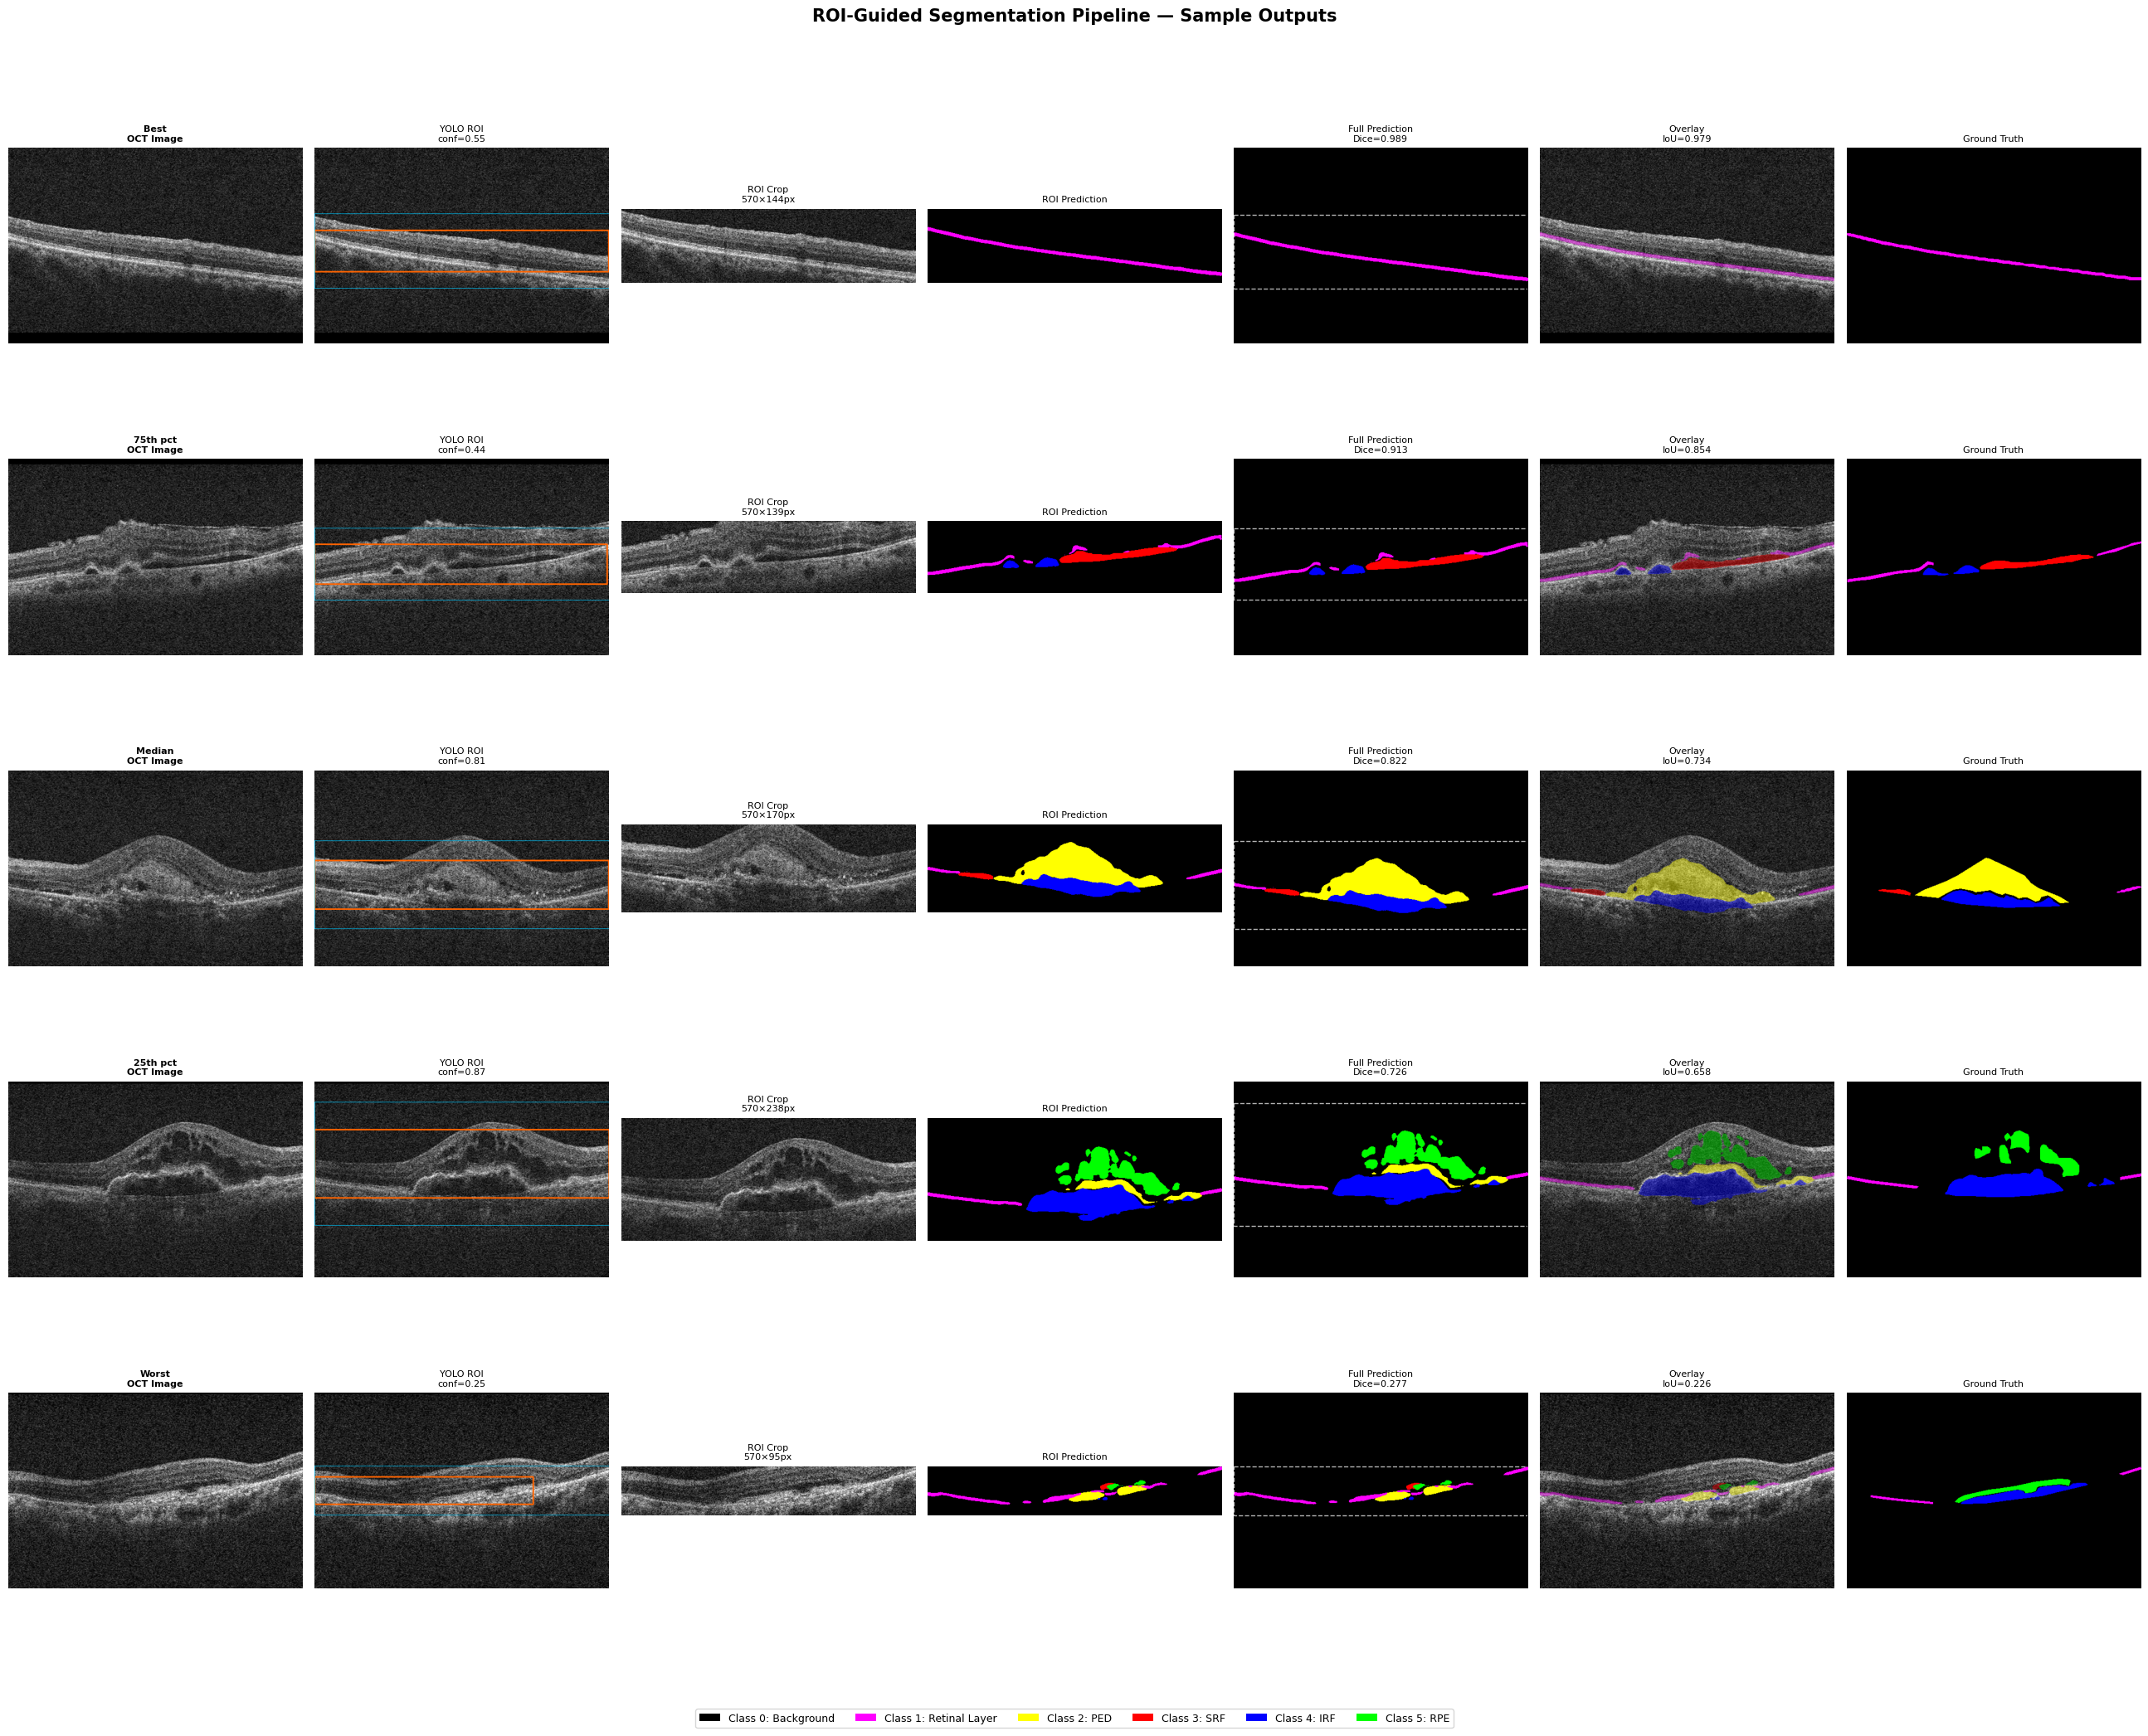

Saved → /content/pipeline_viz_panel.png


In [14]:
N_VIZ = min(5, len(all_results))
# Pick representative samples: highest, median, lowest Dice
sorted_by_dice = sorted(all_results, key=lambda r: r["dice"])
viz_results    = []
if len(all_results) >= 5:
    viz_results = [
        sorted_by_dice[-1],                         # best
        sorted_by_dice[len(sorted_by_dice)*3//4],   # 75th percentile
        sorted_by_dice[len(sorted_by_dice)//2],     # median
        sorted_by_dice[len(sorted_by_dice)//4],     # 25th percentile
        sorted_by_dice[0],                          # worst
    ]
else:
    viz_results = all_results[:N_VIZ]

labels = ["Best", "75th pct", "Median", "25th pct", "Worst"]

fig = plt.figure(figsize=(26, 4 * len(viz_results)))
fig.suptitle("ROI-Guided Segmentation Pipeline — Sample Outputs",
             fontsize=15, fontweight="bold", y=1.01)

n_cols = 7

for row_i, (res, label) in enumerate(zip(viz_results, labels)):
    img_gray      = res["img_gray"]
    img_bgr       = res["img_bgr"]
    box           = res["box"]
    crop          = res["crop"]
    crop_coords   = res["crop_coords"]
    roi_pred_cls  = res["roi_pred_cls"]
    full_pred_cls = res["full_pred_cls"]
    mask_gt_cls   = res["mask_gt_cls"]
    H, W          = img_gray.shape
    cx1, cy1, cx2, cy2 = crop_coords

    # ── Col 1: Full OCT ───────────────────────────────────────────────────────
    ax = fig.add_subplot(len(viz_results), n_cols, row_i * n_cols + 1)
    ax.imshow(img_gray, cmap="gray")
    ax.set_title(f"{label}\nOCT Image", fontsize=8, fontweight="bold")
    ax.axis("off")

    # ── Col 2: OCT + YOLO box ─────────────────────────────────────────────────
    ax = fig.add_subplot(len(viz_results), n_cols, row_i * n_cols + 2)
    vis_box = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).copy()
    x1, y1, x2, y2 = box
    cv2.rectangle(vis_box, (x1, y1), (x2, y2), (255, 100, 0), 2)
    # Crop region (with padding) shown in lighter colour
    cv2.rectangle(vis_box, (cx1, cy1), (cx2, cy2), (0, 200, 255), 1)
    conf_str = f"{res['confidence']:.2f}" if res["detected"] else "fallback"
    ax.imshow(vis_box)
    ax.set_title(f"YOLO ROI\nconf={conf_str}", fontsize=8)
    ax.axis("off")

    # ── Col 3: ROI crop ───────────────────────────────────────────────────────
    ax = fig.add_subplot(len(viz_results), n_cols, row_i * n_cols + 3)
    ax.imshow(crop, cmap="gray")
    ax.set_title(f"ROI Crop\n{crop.shape[1]}×{crop.shape[0]}px", fontsize=8)
    ax.axis("off")

    # ── Col 4: ROI predicted mask ─────────────────────────────────────────────
    ax = fig.add_subplot(len(viz_results), n_cols, row_i * n_cols + 4)
    ax.imshow(mask_to_rgb(roi_pred_cls))
    ax.set_title("ROI Prediction", fontsize=8)
    ax.axis("off")

    # ── Col 5: Full reconstructed prediction ──────────────────────────────────
    ax = fig.add_subplot(len(viz_results), n_cols, row_i * n_cols + 5)
    ax.imshow(mask_to_rgb(full_pred_cls))
    # Draw crop boundary on reconstruction for reference
    rect = plt.Rectangle((cx1, cy1), cx2-cx1, cy2-cy1,
                          linewidth=1, edgecolor="white", facecolor="none",
                          linestyle="--", alpha=0.7)
    ax.add_patch(rect)
    ax.set_title(f"Full Prediction\nDice={res['dice']:.3f}", fontsize=8)
    ax.axis("off")

    # ── Col 6: Overlay (OCT + coloured mask, α-blend) ─────────────────────────
    ax = fig.add_subplot(len(viz_results), n_cols, row_i * n_cols + 6)
    oct_rgb   = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2RGB).astype(np.float32)
    pred_rgb  = mask_to_rgb(full_pred_cls).astype(np.float32)
    # Where prediction is non-background (class != 0), alpha-blend
    fg_mask   = (full_pred_cls != 0)[..., None]
    overlay   = np.where(fg_mask,
                         0.55 * oct_rgb + 0.45 * pred_rgb,
                         oct_rgb).clip(0, 255).astype(np.uint8)
    ax.imshow(overlay)
    ax.set_title(f"Overlay\nIoU={res['iou']:.3f}", fontsize=8)
    ax.axis("off")

    # ── Col 7: Ground truth ───────────────────────────────────────────────────
    ax = fig.add_subplot(len(viz_results), n_cols, row_i * n_cols + 7)
    ax.imshow(mask_to_rgb(mask_gt_cls))
    ax.set_title("Ground Truth", fontsize=8)
    ax.axis("off")

# ── Colour legend ─────────────────────────────────────────────────────────────
legend_elements = [
    mpatches.Patch(facecolor=np.array(CLASS_COLORS_VIZ[i]) / 255,
                   label=f"Class {i}: {CLASS_NAMES[i]}")
    for i in range(NUM_CLASSES)
]
fig.legend(handles=legend_elements, loc="lower center",
           ncol=6, fontsize=9, bbox_to_anchor=(0.5, -0.03))

plt.tight_layout()
viz_path = "/content/pipeline_viz_panel.png"
plt.savefig(viz_path, dpi=130, bbox_inches="tight")
plt.show()
print(f"Saved → {viz_path}")

## Step 13 — Performance Profiling

Measures:
- **Parameter counts** for both models (YOLOv8n + UNet++)
- **FPS** (frames per second) over the test subset
- **Per-stage timing** breakdown (detect / crop / seg / recon)
- **FLOPs** via `fvcore` on a representative crop size (skipped gracefully if unavailable)


In [15]:
# ── Parameter counts ──────────────────────────────────────────────────────────
n_yolo_p = sum(p.numel() for p in yolo_model.model.parameters())
n_seg_p  = sum(p.numel() for p in seg_model.parameters())
n_total_p = n_yolo_p + n_seg_p

print("── Model Parameters ──────────────────────────────────────────")
print(f"  YOLOv8n          : {n_yolo_p:>12,}  ({n_yolo_p/1e6:.2f}M)")
print(f"  UNet++ EffNet-B4 : {n_seg_p:>12,}  ({n_seg_p/1e6:.2f}M)")
print(f"  Total pipeline   : {n_total_p:>12,}  ({n_total_p/1e6:.2f}M)")

# ── Timing breakdown ──────────────────────────────────────────────────────────
stages = {
    "Detection (YOLO)"   : [r["t_detect"]*1000 for r in all_results],
    "Crop"               : [r["t_crop"]*1000    for r in all_results],
    "Segmentation (UNet++)": [r["t_seg"]*1000   for r in all_results],
    "Reconstruction"     : [r["t_recon"]*1000   for r in all_results],
    "Total"              : [r["t_total"]*1000   for r in all_results],
}
print("\n── Timing Breakdown (ms) ─────────────────────────────────────")
print(f"  {'Stage':<26} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8}")
print("  " + "-" * 54)
for name, vals in stages.items():
    print(f"  {name:<26} {np.mean(vals):>8.2f} {np.std(vals):>8.2f} "
          f"{np.min(vals):>8.2f} {np.max(vals):>8.2f}")
print(f"\n  FPS (1000 / mean total ms) : {1000/np.mean(stages['Total']):.2f}")

# ── FLOPs via fvcore ──────────────────────────────────────────────────────────
try:
    from fvcore.nn import FlopCountAnalysis, flop_count_table
    # Use the median crop size as representative input
    crop_sizes = [r["crop"].shape for r in all_results]
    med_h = int(np.median([s[0] for s in crop_sizes]))
    med_w = int(np.median([s[1] for s in crop_sizes]))
    # Snap to stride-32
    med_h = int(np.ceil(med_h / 32) * 32)
    med_w = int(np.ceil(med_w / 32) * 32)

    dummy_input = torch.zeros(1, 1, med_h, med_w).to(device)
    flops       = FlopCountAnalysis(seg_model, dummy_input)
    flops.unsupported_ops_warnings(False)
    flops.uncalled_modules_warnings(False)
    n_flops = flops.total()
    print(f"\n── UNet++ FLOPs (input {med_h}×{med_w}) ──────────────────────")
    print(f"  GFLOPs : {n_flops / 1e9:.3f}")
    print(f"  MFLOPs : {n_flops / 1e6:.1f}")
except ImportError:
    print("\n  fvcore not available — FLOPs skipped (pip install fvcore to enable)")
except Exception as e:
    print(f"\n  FLOPs computation skipped: {e}")

── Model Parameters ──────────────────────────────────────────
  YOLOv8n          :    3,005,843  (3.01M)
  UNet++ EffNet-B4 :   20,812,974  (20.81M)
  Total pipeline   :   23,818,817  (23.82M)

── Timing Breakdown (ms) ─────────────────────────────────────
  Stage                          Mean      Std      Min      Max
  ------------------------------------------------------
  Detection (YOLO)              12.53     2.94     9.38    26.79
  Crop                           0.01     0.00     0.01     0.04
  Segmentation (UNet++)         40.19    11.98    26.37   108.26
  Reconstruction                 0.06     0.02     0.02     0.37
  Total                       2052.61   493.53    97.90  3259.78

  FPS (1000 / mean total ms) : 0.49

── UNet++ FLOPs (input 192×576) ──────────────────────
  GFLOPs : 16.560
  MFLOPs : 16559.7


## Step 14 — Save All Outputs to Google Drive

Saves:
1. **Prediction masks** — full-size colour PNG for every evaluated image
2. **Visualisation panel** — the 7-column figure from Step 12
3. **Metrics CSV** — per-image row with all metric values and timings
4. **Summary JSON** — aggregate statistics for quick comparison


In [16]:
# ── 1. Save prediction masks ──────────────────────────────────────────────────
saved_masks = 0
for res in all_results:
    rgb = mask_to_rgb(res["full_pred_cls"])
    out_path = os.path.join(CONFIG["pred_mask_dir"],
                            os.path.splitext(res["fname"])[0] + "_pred.png")
    cv2.imwrite(out_path, cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR))
    saved_masks += 1
print(f"✅ Saved {saved_masks} prediction masks → {CONFIG['pred_mask_dir']}")

# ── 2. Save main visualisation panel ─────────────────────────────────────────
import shutil
shutil.copy("/content/pipeline_viz_panel.png",
            os.path.join(CONFIG["viz_dir"], "pipeline_viz_panel.png"))
print(f"✅ Saved visualisation panel → {CONFIG['viz_dir']}")

# ── 3. Save per-image metrics CSV ─────────────────────────────────────────────
rows = []
for res in all_results:
    row = {
        "fname"            : res["fname"],
        "detected"         : res["detected"],
        "yolo_conf"        : round(res["confidence"], 4),
        "box_x1"           : res["box"][0],
        "box_y1"           : res["box"][1],
        "box_x2"           : res["box"][2],
        "box_y2"           : res["box"][3],
        "crop_h"           : res["crop"].shape[0],
        "crop_w"           : res["crop"].shape[1],
        "dice"             : round(res["dice"],        4),
        "iou"              : round(res["iou"],         4),
        "pixel_accuracy"   : round(res["pixel_acc"],   4),
        "sensitivity"      : round(res["sensitivity"], 4),
        "specificity"      : round(res["specificity"], 4),
        "t_detect_ms"      : round(res["t_detect"]*1000, 2),
        "t_seg_ms"         : round(res["t_seg"]*1000,    2),
        "t_total_ms"       : round(res["t_total"]*1000,  2),
    }
    for ci, cname in enumerate(CLASS_NAMES):
        row[f"dice_{cname}"] = round(res["per_class_dice"][ci], 4)
        row[f"iou_{cname}"]  = round(res["per_class_iou"][ci],  4)
    rows.append(row)

df = pd.DataFrame(rows)
df.to_csv(CONFIG["metrics_csv"], index=False)
print(f"✅ Saved metrics CSV ({len(df)} rows) → {CONFIG['metrics_csv']}")
print(df[["fname","dice","iou","pixel_accuracy","sensitivity","specificity"]].head(5).to_string(index=False))

# ── 4. Save summary JSON ──────────────────────────────────────────────────────
summary = {
    "pipeline"         : "YOLOv8n + UNet++ EfficientNet-B4",
    "test_fraction"    : CONFIG["test_fraction"],
    "n_images"         : len(all_results),
    "seed"             : CONFIG["seed"],
    "n_detected"       : int(n_detected),
    "detection_rate"   : round(n_detected / len(all_results), 4),
    "dice_mean"        : round(float(np.mean(dice_vals)), 4),
    "dice_std"         : round(float(np.std(dice_vals)),  4),
    "iou_mean"         : round(float(np.mean(iou_vals)),  4),
    "iou_std"          : round(float(np.std(iou_vals)),   4),
    "pixel_acc_mean"   : round(float(np.mean(pa_vals)),   4),
    "sensitivity_mean" : round(float(np.mean(sens_vals)), 4),
    "specificity_mean" : round(float(np.mean(spec_vals)), 4),
    "fps"              : round(float(fps_m), 2),
    "avg_total_ms"     : round(float(np.mean(total_ms)),  2),
    "avg_detect_ms"    : round(float(np.mean(det_ms)),    2),
    "avg_seg_ms"       : round(float(np.mean(seg_ms)),    2),
    "n_yolo_params"    : int(n_yolo_p),
    "n_seg_params"     : int(n_seg_p),
    "n_total_params"   : int(n_total_p),
    "per_class_dice"   : {CLASS_NAMES[i]: round(float(pc_dice_all[i]), 4)
                          for i in range(NUM_CLASSES)},
    "per_class_iou"    : {CLASS_NAMES[i]: round(float(pc_iou_all[i]),  4)
                          for i in range(NUM_CLASSES)},
}
with open(CONFIG["summary_json"], "w") as f:
    json.dump(summary, f, indent=2)
print(f"✅ Saved summary JSON → {CONFIG['summary_json']}")

print("\n── Summary ───────────────────────────────────────────────")
for k, v in summary.items():
    if not isinstance(v, dict):
        print(f"  {k:<22}: {v}")

✅ Saved 609 prediction masks → /content/drive/MyDrive/FYP/pipeline1/pipeline_outputs/pred_masks
✅ Saved visualisation panel → /content/drive/MyDrive/FYP/pipeline1/pipeline_outputs/visualisations
✅ Saved metrics CSV (609 rows) → /content/drive/MyDrive/FYP/pipeline1/pipeline_outputs/metrics.csv
   fname   dice    iou  pixel_accuracy  sensitivity  specificity
2506.png 0.8027 0.7000          0.9662       0.8880       0.9857
1531.png 0.7940 0.7650          0.9867       0.8193       0.9905
 103.png 0.6299 0.5342          0.9628       0.7198       0.9896
1594.png 0.8462 0.7731          0.9794       0.9683       0.9866
2881.png 0.7163 0.6437          0.9801       0.7304       0.9847
✅ Saved summary JSON → /content/drive/MyDrive/FYP/pipeline1/pipeline_outputs/summary.json

── Summary ───────────────────────────────────────────────
  pipeline              : YOLOv8n + UNet++ EfficientNet-B4
  test_fraction         : 0.2
  n_images              : 609
  seed                  : 42
  n_detected      

## Step 15 — Additional Visualisations



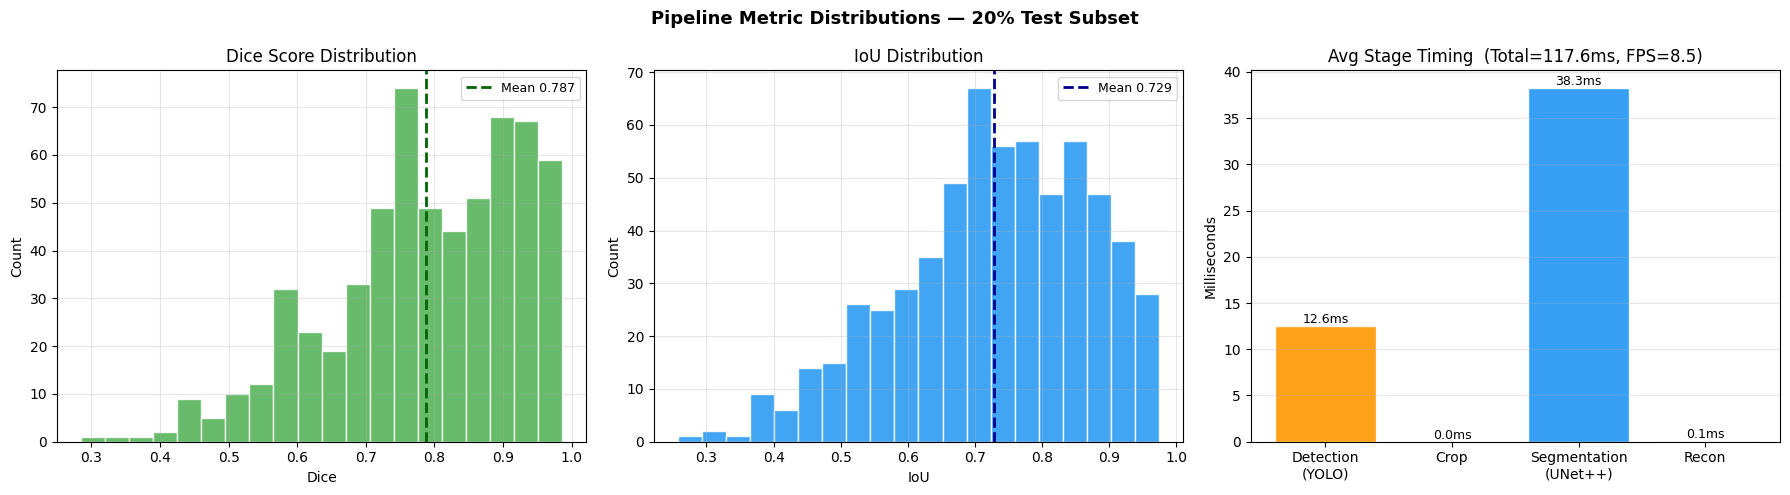

Saved → /content/drive/MyDrive/FYP/pipeline1/pipeline_outputs/visualisations/metric_distributions.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Pipeline Metric Distributions — 20% Test Subset",
             fontsize=13, fontweight="bold")

# Dice histogram
axes[0].hist(dice_vals, bins=20, color="#4CAF50", edgecolor="white", alpha=0.85)
axes[0].axvline(dice_m, color="darkgreen", linestyle="--", linewidth=2,
                label=f"Mean {dice_m:.3f}")
axes[0].set_title("Dice Score Distribution"); axes[0].legend(fontsize=9)
axes[0].set_xlabel("Dice"); axes[0].set_ylabel("Count"); axes[0].grid(alpha=0.3)

# IoU histogram
axes[1].hist(iou_vals, bins=20, color="#2196F3", edgecolor="white", alpha=0.85)
axes[1].axvline(iou_m, color="darkblue", linestyle="--", linewidth=2,
                label=f"Mean {iou_m:.3f}")
axes[1].set_title("IoU Distribution"); axes[1].legend(fontsize=9)
axes[1].set_xlabel("IoU"); axes[1].set_ylabel("Count"); axes[1].grid(alpha=0.3)

# Timing stacked bar
stage_labels = ["Detection\n(YOLO)", "Crop", "Segmentation\n(UNet++)", "Recon"]
stage_means  = [np.mean(det_ms),
                np.mean([r["t_crop"]*1000  for r in all_results]),
                np.mean(seg_ms),
                np.mean([r["t_recon"]*1000 for r in all_results])]
colors = ["#FF9800", "#9C27B0", "#2196F3", "#4CAF50"]
axes[2].bar(stage_labels, stage_means, color=colors, edgecolor="white", alpha=0.9)
for xi, (lbl, val) in enumerate(zip(stage_labels, stage_means)):
    axes[2].text(xi, val + 0.3, f"{val:.1f}ms", ha="center", fontsize=9)
axes[2].set_title(f"Avg Stage Timing  (Total={np.mean(total_ms):.1f}ms, FPS={fps_m:.1f})")
axes[2].set_ylabel("Milliseconds"); axes[2].grid(alpha=0.3, axis="y")

plt.tight_layout()
dist_path = os.path.join(CONFIG["viz_dir"], "metric_distributions.png")
plt.savefig(dist_path, dpi=130, bbox_inches="tight")
plt.show()
print(f"Saved → {dist_path}")

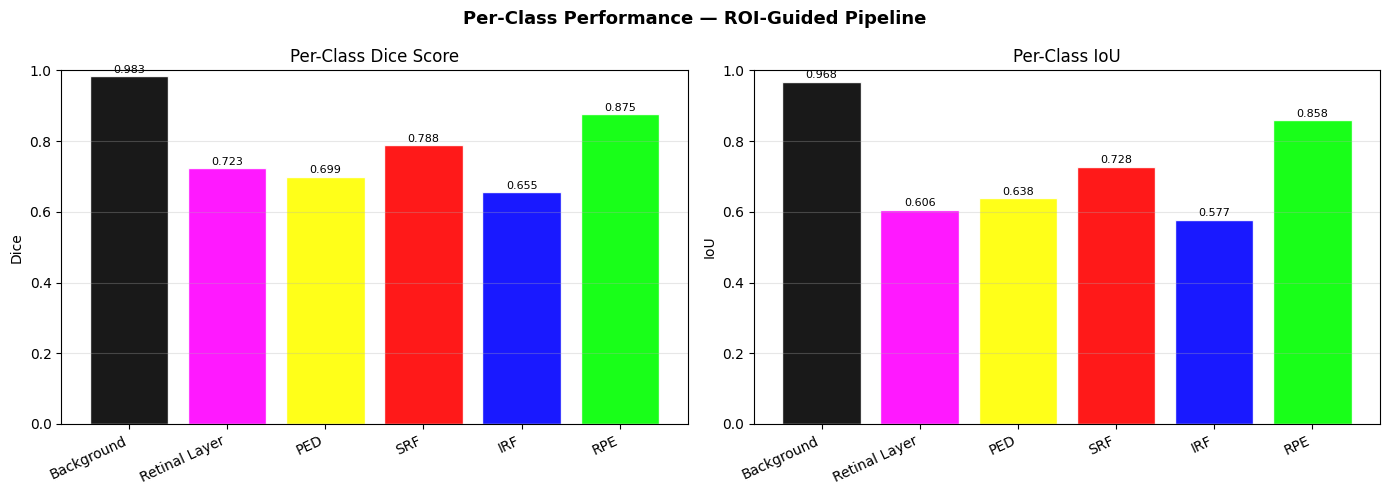

Saved → /content/drive/MyDrive/FYP/pipeline1/pipeline_outputs/visualisations/per_class_metrics.png


In [ ]:
# ── Per-class Dice bar chart ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Per-Class Performance — ROI-Guided Pipeline",
             fontsize=13, fontweight="bold")

x      = np.arange(NUM_CLASSES)
colors = [np.array(CLASS_COLORS_VIZ[i]) / 255 for i in range(NUM_CLASSES)]

# Dice
axes[0].bar(x, pc_dice_all, color=colors, edgecolor="white", alpha=0.9)
axes[0].set_xticks(x); axes[0].set_xticklabels(CLASS_NAMES, rotation=25, ha="right")
axes[0].set_ylim([0, 1]); axes[0].set_title("Per-Class Dice Score")
axes[0].set_ylabel("Dice"); axes[0].grid(alpha=0.3, axis="y")
for xi, val in enumerate(pc_dice_all):
    axes[0].text(xi, val + 0.01, f"{val:.3f}", ha="center", fontsize=8)

# IoU
axes[1].bar(x, pc_iou_all, color=colors, edgecolor="white", alpha=0.9)
axes[1].set_xticks(x); axes[1].set_xticklabels(CLASS_NAMES, rotation=25, ha="right")
axes[1].set_ylim([0, 1]); axes[1].set_title("Per-Class IoU")
axes[1].set_ylabel("IoU"); axes[1].grid(alpha=0.3, axis="y")
for xi, val in enumerate(pc_iou_all):
    axes[1].text(xi, val + 0.01, f"{val:.3f}", ha="center", fontsize=8)

plt.tight_layout()
pc_path = os.path.join(CONFIG["viz_dir"], "per_class_metrics.png")
plt.savefig(pc_path, dpi=130, bbox_inches="tight")
plt.show()
print(f"Saved → {pc_path}")

---

## ✅ Pipeline Complete

### Output files saved to Google Drive

| File | Description |
|------|-------------|
| `pipeline_outputs/pred_masks/*.png` | Full-size colour prediction mask per image |
| `pipeline_outputs/visualisations/pipeline_viz_panel.png` | 7-column sample panel |
| `pipeline_outputs/visualisations/metric_distributions.png` | Dice/IoU histograms + timing |
| `pipeline_outputs/visualisations/per_class_metrics.png` | Per-class Dice & IoU bar charts |
| `pipeline_outputs/metrics.csv` | Per-image metrics + timings |
| `pipeline_outputs/summary.json` | Aggregate results (for comparison tables) |

### Key design decisions

| Decision | Rationale |
|----------|-----------|
| 20% random subset with fixed seed | Reproducible lightweight evaluation |
| Highest-confidence YOLO box | Single clean ROI; avoids multi-box ambiguity |
| x_pad=30%, y_pad=10% | Lesions are laterally elongated; wider context improves seg quality |
| Native crop size (no resize) | Preserves lesion detail; avoids information loss |
| Stride-32 padding | EfficientNet-B4 encoder requirement; pad-then-crop preserves spatial accuracy |
| Reconstruct into full-image coords | Enables fair evaluation against full-size GT masks |
| Fallback to full image if no YOLO detection | Ensures all images produce a metric; flags low-confidence cases |

### Next steps

- Export YOLOv8n to ONNX / TFLite for edge deployment
- Quantise UNet++ to INT8 for further latency reduction
- Compare `summary.json` against baseline (no-ROI) metrics to quantify compute savings
